# Numeric Representations:  In-Class Exercises

[Open in Colab](https://colab.research.google.com/github/sdrangan/hwdesign/blob/main/units/unit02_numbers/numbers_inclass.ipynb)

To motivate fixed point representations, in this exercise, let's consider a problem of translating a basic floating point operation to a limited number of values.  We will see some ways to do this in the class, but let's think about how we would do this simple problem to get you thinking about what is involved.

Consider a simple a quadratic function:

Text(0, 0.5, 'y')

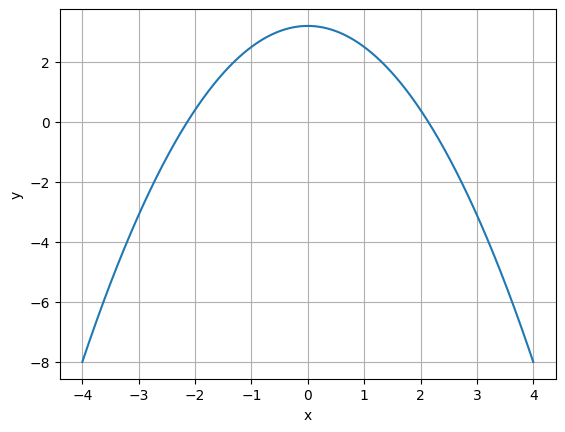

In [1]:
import numpy as np
import matplotlib.pyplot as plt

nx = 1000
x = np.linspace(-4, 4, nx)
y = 3.2 - 0.7 * (x**2)

plt.plot(x, y)
plt.grid()
plt.xlabel('x')
plt.ylabel('y')


Now suppose we have to perform the same computation in a small number, say `b=8` bits.
Think of a way to do the following:

* **Encode** each of the values `x` to `b` bits
* **Compute** `y` from the encoded values of `x`.  You can only use a `b x b` integer multiplier and adders.  Also, you must store the final value of `y` back in `b` bits
* **Decode** the `b` bit values of `y` back to floating point numbers
* Measure the **approximation error**  of using just `b` bits.

In [4]:
# Fixed-point parameters
b = 8  # number of bits
nf = 4  # number of fractional bits
ni = b - nf  # number of integer bits

# Determine the range we can represent
xmax = (2**(b-1) - 1) / (2**nf)
xmin = -(2**(b-1)) / (2**nf)
print(f"Range: [{xmin:.2f}, {xmax:.2f}]")

# Encode x values to fixed-point (scale and round)
x_fixp = np.clip(x, xmin, xmax)  # clip to representable range
x_encoded = np.round(x_fixp * (2**nf)).astype(np.int8)

# Fixed-point coefficients for y = 3.2 - 0.7*x^2
# c0 = 3.2, c1 = -0.7
c0_encoded = int(np.round(3.2 * (2**nf)))
c1_encoded = int(np.round(-0.7 * (2**nf)))

# Compute y in fixed-point using only integer operations
# y = c0 + c1 * x^2
# When multiplying two Qm.n numbers, result is Q(2m).(2n), so shift right by n bits
x2_encoded = (x_encoded.astype(np.int32) * x_encoded.astype(np.int32)) >> nf  # x^2 in Q4.4
y_temp = c0_encoded + ((c1_encoded * x2_encoded) >> nf)  # Final result in Q4.4
y_encoded = np.clip(y_temp, -128, 127).astype(np.int8)

# Decode y back to floating point
y_fixp = y_encoded / (2**nf)

print(f"c0_encoded: {c0_encoded}, c1_encoded: {c1_encoded}")

Range: [-8.00, 7.94]
c0_encoded: 51, c1_encoded: -11


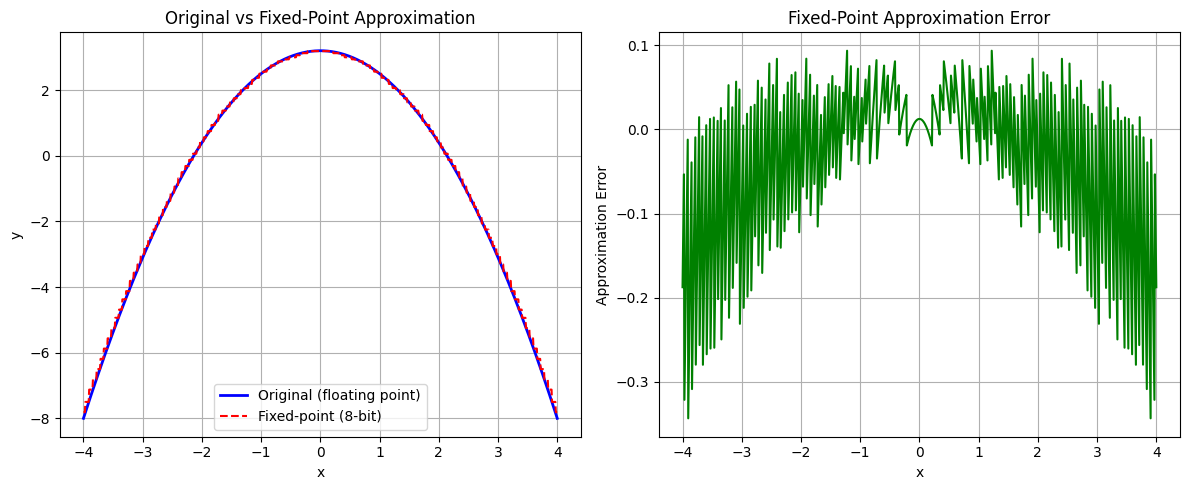


Error Metrics:
Mean Absolute Error (MAE): 0.0648
Root Mean Square Error (RMSE): 0.0919
Maximum Absolute Error: 0.3433


In [5]:
# Compare results
plt.figure(figsize=(12, 5))

# Plot original vs fixed-point approximation
plt.subplot(1, 2, 1)
plt.plot(x, y, 'b-', label='Original (floating point)', linewidth=2)
plt.plot(x, y_fixp, 'r--', label=f'Fixed-point ({b}-bit)', linewidth=1.5)
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Original vs Fixed-Point Approximation')

# Plot approximation error
plt.subplot(1, 2, 2)
error = y - y_fixp
plt.plot(x, error, 'g-')
plt.grid()
plt.xlabel('x')
plt.ylabel('Approximation Error')
plt.title('Fixed-Point Approximation Error')

plt.tight_layout()
plt.show()

# Calculate error metrics
mae = np.mean(np.abs(error))
mse = np.mean(error**2)
rmse = np.sqrt(mse)
max_error = np.max(np.abs(error))

print(f"\nError Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Maximum Absolute Error: {max_error:.4f}")